[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/uahccre/ncs_workshop/blob/main/cnn_training.ipynb)

## Making a Copy of the Notebook
1. Click the "Open in Colab" Button
2. The file will open in Read Only mode. Go to File -> Save a Copy in Drive
3. A new tab will open with your editable copy for the rest of the lab.
4. Go to "Edit" and select "Clear All Outputs" to ensure we're starting fresh.

## Training A CNN on CIFAR-10
We will do a hands on walkthrough that does the following:
- Loads real images
- Create a Convolutional Neural Network (CNN)
- Watch the untrained CNN fail
- Train the CNN
- Test it
- See how much it learned

## Setting up the Runtime
Before we run the notebook, do the following: go to **Runtime** -> **Change runtime type** -> **T4 GPU** -> **Save**.

The training will run much faster on a GPU as opposed to the default CPU.


## Importing the Required Libraries
We'll use `torch` to create, train and run our CNN model.

We'll use `torchvision` to load our CIFAR-10 dataset.

We'll use `matplotlib` to visualize our results.

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [ ]:
# Verify our notebook is set up to use the T4 GPU
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

Using device:  cuda


In [ ]:
# Load the CIFAR-10 data set. It contains 32x32 color images from 10 everyday classes
transform = transforms.ToTensor()
train_data = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_data = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=128, shuffle=False)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print(f"{len(train_data):,} training images, {len(test_data):,} test images")

100%|██████████| 170M/170M [01:16<00:00, 2.22MB/s]


50,000 training images, 10,000 test images


## Peek at the Data

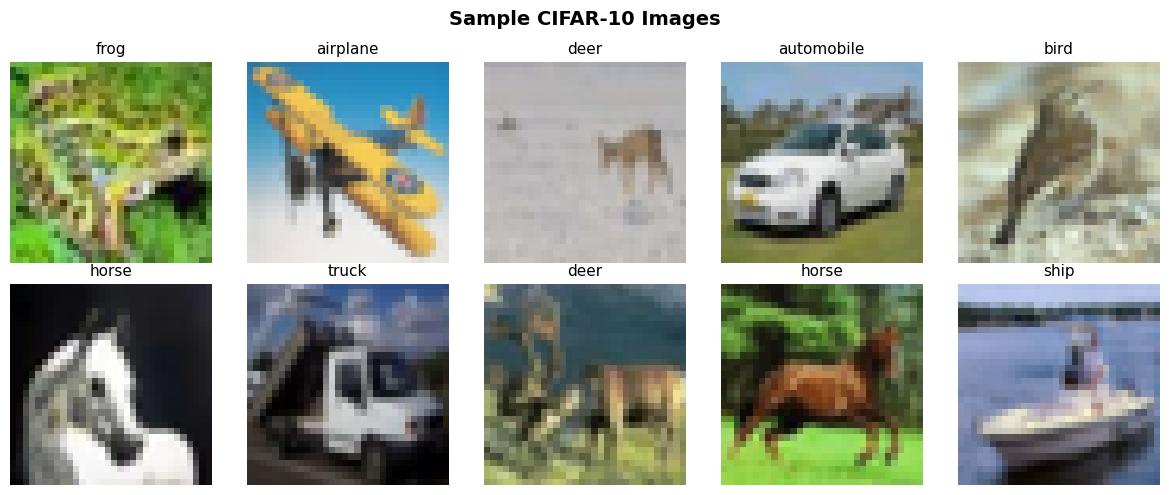

In [ ]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].permute(1, 2, 0)) # C,H,W -> H,W,C for display
    ax.set_title(class_names[labels[i].item()], fontsize=11)
    ax.axis("off")
plt.suptitle("Sample CIFAR-10 Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Define the CNN Model

In [ ]:
class TinyCNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(3, 32, kernel_size=3) # 3 color channels in, 32 filters
    self.pool = nn.MaxPool2d(2, 2)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3) # 32 in from Conv1, 64 filters
    self.fc1 = nn.Linear(64 * 6 * 6, 128) # 64 maps of 6x6 after two Conv+Pool, 128 features out
    self.fc2 = nn.Linear(128, 10) # 10 class scores

  def forward(self, x):
    # This is the actual prediction method the network uses for inference
    x = self.pool(torch.relu(self.conv1(x))) # 32 -> 30 -> 15
    x = self.pool(torch.relu(self.conv2(x))) # 15 -> 13 -> 6
    x = torch.flatten(x, 1) # Create a 1D vector from the pooling outputs
    x = torch.relu(self.fc1(x))
    return self.fc2(x)

model = TinyCNN().to(device)
print(f"Model ready: {sum(p.numel() for p in model.parameters()):,} parameters")


Model ready: 315,722 parameters


### Define Helper Functions

In [ ]:
@torch.no_grad()
def test_accuracy(model):
    model.eval()
    correct = total = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images).argmax(1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return 100 * correct / total

@torch.no_grad()
def show_predictions(model, title):
    model.eval()
    images, labels = next(iter(test_loader))
    preds = model(images.to(device)).argmax(1).cpu()
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i].permute(1, 2, 0))
        right = preds[i].item() == labels[i].item()
        ax.set_title(f"pred: {class_names[preds[i]]}\ntrue: {class_names[labels[i]]}",
                     color="green" if right else "red", fontsize=10)
        ax.axis("off")
    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

## Run the Untrained Network
The weights are completely random right now. The model has learned nothing. With 10 classes the model will score around 10%.

Untrained test accuracy: 8.5%   (random guessing)


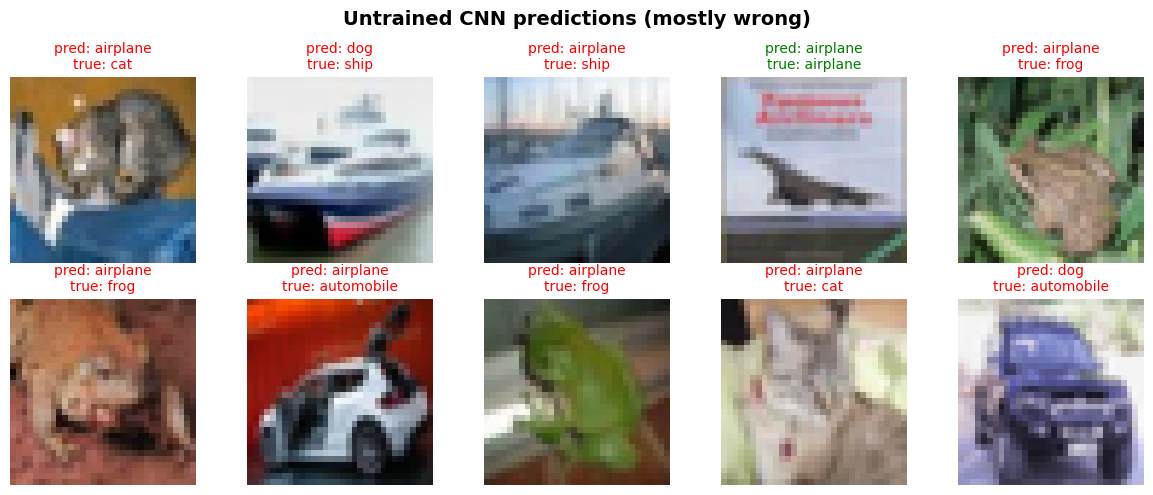

In [ ]:
print(f"Untrained test accuracy: {test_accuracy(model):.1f}%   (random guessing)")
show_predictions(model, "Untrained CNN predictions (mostly wrong)")

## Train the CNN

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 10
train_losses, train_accs = [], []

for epoch in range(EPOCHS):
  model.train()
  running_loss = correct = total = 0
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad() # clear the previous gradients
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward() # backpropagation
    optimizer.step() # gradient descent update
    running_loss += loss.item() * labels.size(0)
    correct += (outputs.argmax(1) == labels).sum().item()
    total += labels.size(0)
  train_losses.append(running_loss / total)
  train_accs.append(100 *correct / total)
  print(f"Epoch {epoch+1:2d}/{EPOCHS} loss {train_losses[-1]:.3f}   train acc {train_accs[-1]:.1f}%")

Epoch  1/10 loss 1.594   train acc 42.3%
Epoch  2/10 loss 1.257   train acc 55.5%
Epoch  3/10 loss 1.095   train acc 61.7%
Epoch  4/10 loss 1.005   train acc 65.0%
Epoch  5/10 loss 0.932   train acc 67.5%
Epoch  6/10 loss 0.872   train acc 69.7%
Epoch  7/10 loss 0.810   train acc 71.8%
Epoch  8/10 loss 0.770   train acc 73.1%
Epoch  9/10 loss 0.715   train acc 75.3%
Epoch 10/10 loss 0.677   train acc 76.6%


## Test the Trained Network

In [ ]:
print(f"Trained test accuracy: {test_accuracy(model):.1f}%")

Trained test accuracy: 70.7%


## Visualize what the CNN Learned

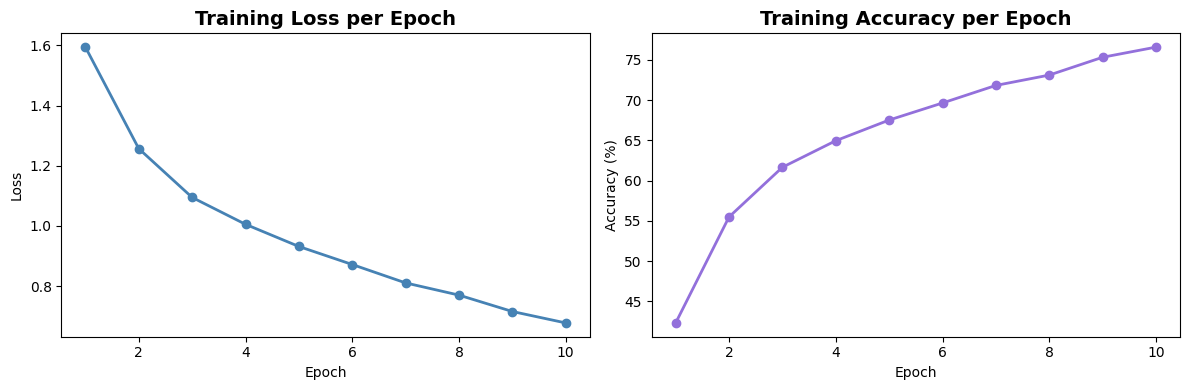

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, train_losses, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Training Loss per Epoch', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

axes[1].plot(epochs_range, train_accs, 'o-', color='mediumpurple', linewidth=2)
axes[1].set_title('Training Accuracy per Epoch', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')

plt.tight_layout()
plt.show()

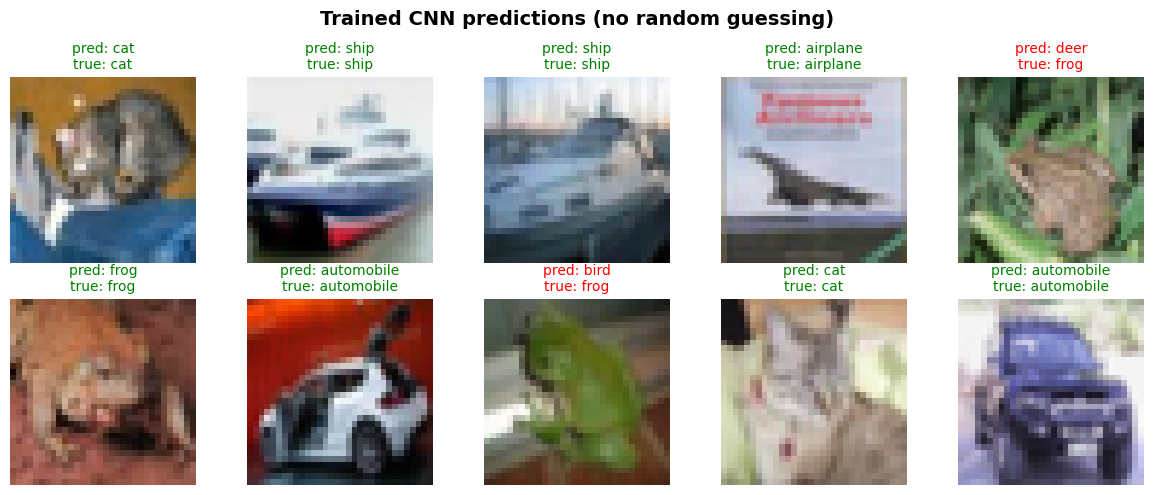

In [ ]:
show_predictions(model, "Trained CNN predictions (no random guessing)")